Train years: 1933 to 2018
Test years: [2019 2020 2021 2022 2023]
[rep 1/1] epoch  100 | train_recon_relRMSE=0.219534 | val_recon_relRMSE=0.203535
[rep 1/1] epoch  200 | train_recon_relRMSE=0.136214 | val_recon_relRMSE=0.104012
           forecast_relRMSE(2019-2023)=0.361453
[rep 1/1] epoch  300 | train_recon_relRMSE=0.095084 | val_recon_relRMSE=0.048350
[rep 1/1] epoch  400 | train_recon_relRMSE=0.088946 | val_recon_relRMSE=0.040668
           forecast_relRMSE(2019-2023)=0.186538
[rep 1/1] epoch  500 | train_recon_relRMSE=0.086977 | val_recon_relRMSE=0.039172
[rep 1/1] epoch  600 | train_recon_relRMSE=0.086586 | val_recon_relRMSE=0.040384
           forecast_relRMSE(2019-2023)=0.182820
[rep 1/1] epoch  700 | train_recon_relRMSE=0.086409 | val_recon_relRMSE=0.039930
[rep 1/1] epoch  800 | train_recon_relRMSE=0.087255 | val_recon_relRMSE=0.040791
           forecast_relRMSE(2019-2023)=0.167270
[rep 1/1] epoch  900 | train_recon_relRMSE=0.087835 | val_recon_relRMSE=0.040521
[rep 1/1] epoc

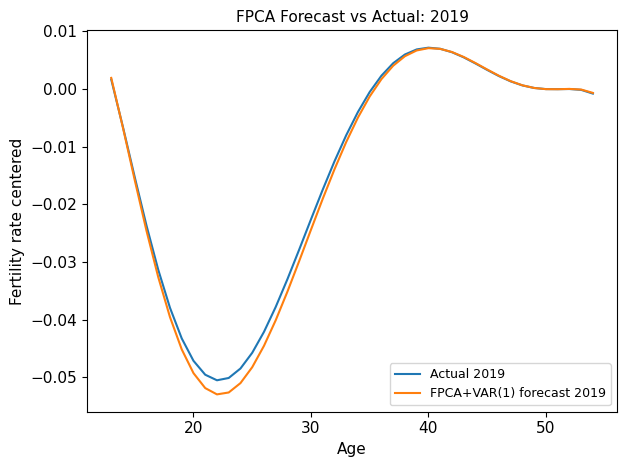

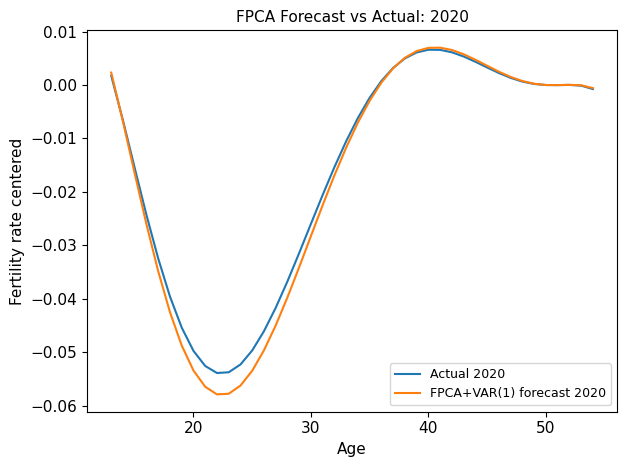

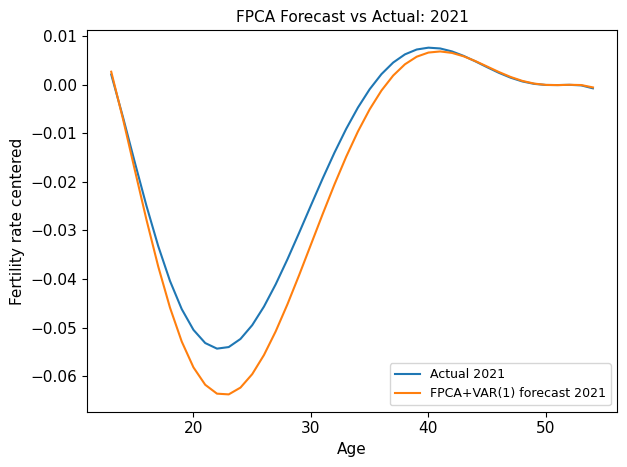

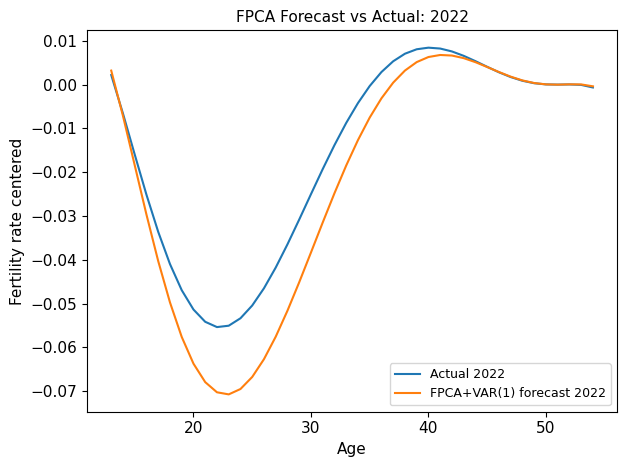

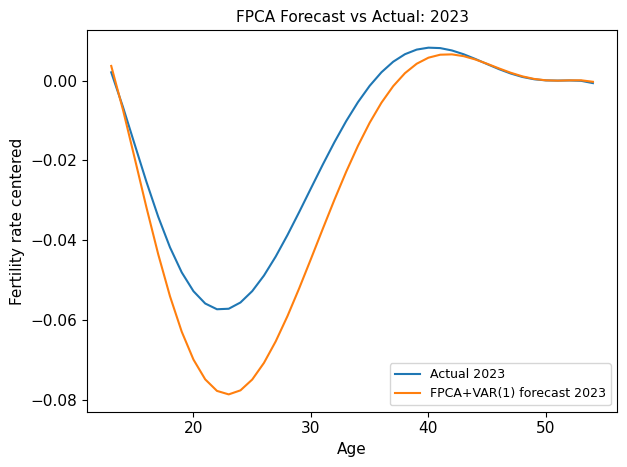

FPCA+VAR(1) forecast relRMSE: 0.3285679519176483
FAE+VAR(1) forecast relRMSE: 0.13095644297172526


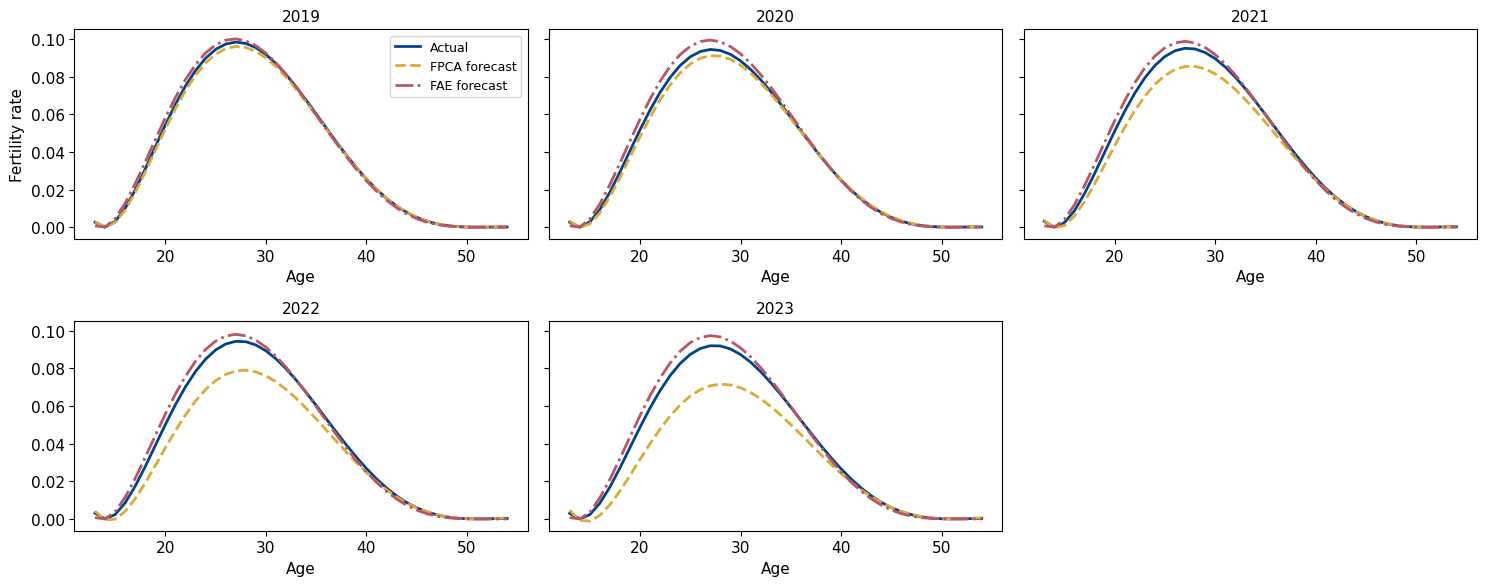

Saved combined forecast plot to: fertility_forecasts_orig_constrained.pdf


In [15]:

# ============================================================
# Functional Autoencoder + Latent VAR Forecasting
# USA Fertility Data
#
# RMarkdown version using reticulate.
# ============================================================

import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================
# Load and preprocess fertility data
# ============================================================

def load_and_preprocess_fertility(
    csv_path=r"D:\Mobina\Marquette\FAE Codes\FAE-Time Series\USAfertility.csv",
    spline_s=50.0,
    sqrt_smooth=True
):
    """
    Reads USA fertility data and smooths each year's fertility curve over age.

    sqrt_smooth=True smooths sqrt(rate), then squares back.
    This helps preserve nonnegativity before FAE training.
    """

    df = pd.read_csv(csv_path)

    ages = df["Age"].to_numpy(dtype=float)
    year_cols = [c for c in df.columns if c != "Age"]
    years = np.array([int(c) for c in year_cols])

    rates = df[year_cols].to_numpy(dtype=float)

    smoothed = np.zeros_like(rates, dtype=float)

    for i in range(rates.shape[1]):
        y = rates[:, i]

        if sqrt_smooth:
            y_safe = np.maximum(y, 0.0)
            spl = UnivariateSpline(ages, np.sqrt(y_safe), s=spline_s)
            smoothed[:, i] = spl(ages) ** 2
        else:
            spl = UnivariateSpline(ages, y, s=spline_s)
            smoothed[:, i] = spl(ages)

    # rows = years, columns = ages
    x_raw = smoothed.T.astype(np.float32)

    x = torch.tensor(x_raw, dtype=torch.float32)

    # Keep your original centering idea
    x_mean = torch.mean(x, dim=0)
    x_centered = x - x_mean

    # rescale ages to [0, 1] for basis construction
    tpts_np = ages.astype(float)
    tpts_rescale = (tpts_np - tpts_np.min()) / (tpts_np.max() - tpts_np.min())
    tpts = torch.tensor(tpts_rescale, dtype=torch.float32)

    return {
        "df": df,
        "ages": ages,
        "years": years,
        "rates": rates,
        "smoothed": smoothed,
        "x_raw": x_raw,
        "x": x,
        "x_mean": x_mean,
        "x_centered": x_centered,
        "tpts": tpts
    }


def make_time_split(
    x_centered,
    years,
    train_end_year=2018,
    test_years=np.array([2019, 2020, 2021, 2022, 2023])
):
    train_mask = years <= train_end_year
    test_mask = np.isin(years, test_years)

    train_years = years[train_mask]
    test_years_present = years[test_mask]

    if len(test_years_present) != len(test_years):
        missing = set(test_years.tolist()) - set(test_years_present.tolist())
        raise ValueError(f"Missing test years in CSV: {sorted(list(missing))}")

    x_train_all = x_centered[train_mask]
    x_test_all = x_centered[test_mask]

    # chronological order for VAR
    train_order = np.argsort(train_years)
    test_order = np.argsort(test_years_present)

    train_years = train_years[train_order]
    test_years_present = test_years_present[test_order]

    x_train_all = x_train_all[train_order]
    x_test_all = x_test_all[test_order]

    return {
        "x_train_all": x_train_all,
        "x_test_all": x_test_all,
        "train_years": train_years,
        "test_years": test_years_present
    }


# ============================================================
# Basis construction: Fourier or B-spline
# ============================================================

class BasisFCBuilder:
    """
    Builds basis matrix evaluated on tpts.
    Output shape: [n_time, n_basis]
    """

    def __init__(
        self,
        n_basis=20,
        basis_type="Fourier",
        custom_basis_fn=None,
        bspline_degree=3
    ):
        self.n_basis = n_basis
        self.basis_type = basis_type
        self.basis_type_l = basis_type.lower()
        self.custom_basis_fn = custom_basis_fn
        self.bspline_degree = bspline_degree

    def __call__(self, tpts):
        return self.build(tpts)

    def build(self, tpts):
        if self.custom_basis_fn is not None:
            B = self.custom_basis_fn(tpts)
            if not torch.is_tensor(B):
                B = torch.tensor(B, dtype=torch.float32)
            return B.float()

        if self.basis_type_l == "fourier":
            return self._build_fourier(tpts)

        if self.basis_type_l in ("bspline", "b-spline", "b_spline"):
            return self._build_bspline(tpts, degree=self.bspline_degree)

        raise ValueError("basis_type must be 'Fourier' or 'Bspline'.")

    def _build_fourier(self, tpts):
        t = tpts.flatten()
        t_min = t.min()
        t_max = t.max()
        denom = (t_max - t_min).clamp_min(1e-8)
        tau = (t - t_min) / denom

        n_time = tpts.shape[0]
        n_basis = self.n_basis
        device = tpts.device

        B = torch.zeros(n_time, n_basis, dtype=torch.float32, device=device)

        if n_basis > 0:
            B[:, 0] = 1.0

        k = 1
        idx = 1

        while idx < n_basis:
            B[:, idx] = torch.sin(2.0 * math.pi * k * tau)
            idx += 1

            if idx < n_basis:
                B[:, idx] = torch.cos(2.0 * math.pi * k * tau)
                idx += 1

            k += 1

        return B

    def _build_bspline(self, tpts, degree=3):
        t = tpts.flatten()
        t_min = t.min()
        t_max = t.max()
        denom = (t_max - t_min).clamp_min(1e-8)
        tau = (t - t_min) / denom
        tau_np = tau.detach().cpu().numpy()

        n_time = tau_np.shape[0]
        n_basis = self.n_basis
        p = degree

        if n_basis < p + 1:
            raise ValueError(
                f"Bspline: n_basis={n_basis} must be at least degree+1={p + 1}."
            )

        n_int = max(n_basis - p - 1, 0)

        if n_int > 0:
            interior = np.linspace(0.0, 1.0, n_int + 2)[1:-1]
            knots = np.concatenate((np.zeros(p + 1), interior, np.ones(p + 1)))
        else:
            knots = np.concatenate((np.zeros(p + 1), np.ones(p + 1)))

        N = np.zeros((n_basis, n_time), dtype=np.float64)

        for i in range(n_basis):
            left = knots[i]
            right = knots[i + 1]
            N[i, :] = np.where((tau_np >= left) & (tau_np < right), 1.0, 0.0)

        N[-1, tau_np == 1.0] = 1.0

        for k in range(1, p + 1):
            N_next = np.zeros_like(N)

            for i in range(n_basis):
                denom_left = knots[i + k] - knots[i]

                if denom_left > 0:
                    coeff_left = (tau_np - knots[i]) / denom_left
                    N_left = coeff_left * N[i, :]
                else:
                    N_left = 0.0

                denom_right = knots[i + k + 1] - knots[i + 1] if (i + 1) < n_basis else 0.0

                if denom_right > 0 and (i + 1) < n_basis:
                    coeff_right = (knots[i + k + 1] - tau_np) / denom_right
                    N_right = coeff_right * N[i + 1, :]
                else:
                    N_right = 0.0

                N_next[i, :] = N_left + N_right

            N = N_next

        B_np = N.T
        B = torch.tensor(B_np, dtype=torch.float32, device=tpts.device)

        return B


# ============================================================
# Nonlinear Functional Autoencoder
# ============================================================

class FAEVanilla(nn.Module):
    def __init__(
        self,
        n_basis_project,
        n_rep,
        n_basis_revert,
        init_weight_sd=None
    ):
        super().__init__()

        # Nonlinear FAE
        self.fc1 = nn.Linear(n_basis_project, 100, bias=False)
        self.fc2 = nn.Linear(100, n_rep, bias=False)
        self.fc3 = nn.Linear(n_rep, 100, bias=False)
        self.fc4 = nn.Linear(100, n_basis_revert, bias=False)
        self.activation = nn.ReLU()

        if init_weight_sd is not None:
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.normal_(m.weight, mean=0.0, std=init_weight_sd)

    def project(self, x, tpts, basis_fc):
        t = tpts.flatten()
        dt = t[1:] - t[:-1]

        zero = torch.zeros(1, device=x.device, dtype=x.dtype)
        W = 0.5 * torch.cat([zero, dt]) + 0.5 * torch.cat([dt, zero])

        n_time = x.shape[1]

        if basis_fc.shape[0] == n_time:
            B = basis_fc
        elif basis_fc.shape[1] == n_time:
            B = basis_fc.T
        else:
            raise RuntimeError(
                f"basis_fc shape {tuple(basis_fc.shape)} not compatible with n_time={n_time}"
            )

        return (x * W) @ B

    def revert(self, coef, basis_fc):
        n_basis = coef.shape[1]

        if basis_fc.shape[1] == n_basis:
            return coef @ basis_fc.T
        elif basis_fc.shape[0] == n_basis:
            return coef @ basis_fc
        else:
            raise RuntimeError(
                f"basis_fc shape {tuple(basis_fc.shape)} not compatible with n_basis={n_basis}"
            )

    def decode_from_rep(self, rep, basis_fc_revert):
        t2 = self.activation(self.fc3(rep))
        coef = self.fc4(t2)
        x_hat = self.revert(coef, basis_fc_revert)
        return x_hat, coef

    def forward(self, x, tpts, basis_fc_project, basis_fc_revert):
        feature = self.project(x, tpts, basis_fc_project)

        t1 = self.activation(self.fc1(feature))
        rep = self.fc2(t1)

        t2 = self.activation(self.fc3(rep))
        coef = self.fc4(t2)

        x_hat = self.revert(coef, basis_fc_revert)

        return x_hat, rep, feature, coef


# ============================================================
# Losses and constraints
# ============================================================

def diff_penalty(coef):
    delta = coef[:, 2:] - 2 * coef[:, 1:-1] + coef[:, :-2]
    return torch.mean(torch.sum(delta ** 2, dim=1))


def fertility_shape_penalty(
    x_hat_centered,
    x_mean,
    ages_t,
    lambda_nonneg=1e-2,
    lambda_tail=1e-3,
    tail_age=48.0
):
    """
    Soft constraints on original fertility scale.

    x_hat_centered is the FAE output.
    x_hat_orig = x_hat_centered + x_mean.
    """

    x_hat_orig = x_hat_centered + x_mean.view(1, -1)

    # Penalize negative rates
    nonneg_pen = torch.mean(torch.relu(-x_hat_orig) ** 2)

    # Penalize tail values near age 50
    tail_mask = ages_t >= tail_age

    if tail_mask.any():
        tail_pen = torch.mean(x_hat_orig[:, tail_mask] ** 2)
    else:
        tail_pen = torch.tensor(0.0, device=x_hat_centered.device)

    return lambda_nonneg * nonneg_pen + lambda_tail * tail_pen


def relative_mse_from_preds(y_hat, y_true, eps=1e-12):
    mse = torch.mean((y_hat - y_true) ** 2)
    var = torch.var(y_true, unbiased=False)
    return float((mse / var.clamp_min(eps)).detach().cpu())


def relative_rmse_from_preds(y_hat, y_true, eps=1e-12):
    return math.sqrt(relative_mse_from_preds(y_hat, y_true, eps=eps))


# ============================================================
# VAR(1) forecasting
# ============================================================

def fit_var1(H, ridge=1e-8):
    """
    H: [T, K]
    Fits H_t = b + A H_{t-1}
    """

    T, K = H.shape

    if T < 2:
        raise ValueError("Need at least 2 time points to fit VAR(1).")

    X = H[:-1, :]
    Y = H[1:, :]

    X_aug = np.hstack([np.ones((T - 1, 1)), X])

    XtX = X_aug.T @ X_aug
    reg = ridge * np.eye(XtX.shape[0])

    B = np.linalg.solve(XtX + reg, X_aug.T @ Y)

    b = B[0, :]
    A = B[1:, :].T

    return b, A


def forecast_var1(h_last, b, A, steps):
    K = h_last.shape[0]
    out = np.zeros((steps, K), dtype=float)

    h = h_last.copy()

    for i in range(steps):
        h = b + (A @ h)
        out[i, :] = h

    return out


# ============================================================
# Train and evaluate FAE
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    loss_fn,
    device,
    tpts,
    basis_fc_project,
    basis_fc_revert,
    pen="diff",
    lamb=0.0,
    x_mean=None,
    ages_t=None,
    lambda_nonneg=0.0,
    lambda_tail=0.0,
    tail_age=48.0
):
    model.train()

    total_loss = 0.0
    total_score_loss = 0.0
    n_batches = 0

    for x_batch in loader:
        x_batch = x_batch.to(device).float()

        optimizer.zero_grad()

        x_hat, rep, feature, coef = model(
            x_batch,
            tpts,
            basis_fc_project,
            basis_fc_revert
        )

        loss = loss_fn(x_hat, x_batch)

        score_loss = 0.0

        if feature.shape == coef.shape:
            score_loss = loss_fn(feature, coef)
            total_score_loss += float(score_loss.detach().cpu())

        # New: biological fertility constraints on original scale
        if x_mean is not None and ages_t is not None:
            loss = loss + fertility_shape_penalty(
                x_hat,
                x_mean=x_mean,
                ages_t=ages_t,
                lambda_nonneg=lambda_nonneg,
                lambda_tail=lambda_tail,
                tail_age=tail_age
            )

        # Existing smoothness penalty
        if pen == "diff" and lamb > 0:
            loss = loss + lamb * diff_penalty(coef)

        loss.backward()
        optimizer.step()

        total_loss += float(loss.detach().cpu())
        n_batches += 1

    return total_loss / max(n_batches, 1), total_score_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(
    model,
    x_data,
    loss_fn,
    device,
    tpts,
    basis_fc_project,
    basis_fc_revert
):
    model.eval()

    x_data = x_data.to(device).float()

    x_hat, rep, feature, coef = model(
        x_data,
        tpts,
        basis_fc_project,
        basis_fc_revert
    )

    loss = loss_fn(x_hat, x_data)

    return x_hat, rep, float(loss.detach().cpu()), coef


@torch.no_grad()
def latent_forecast_and_decode(
    model,
    H_train,
    steps,
    device,
    basis_fc_revert
):
    H_np = H_train.detach().cpu().numpy()

    b, A = fit_var1(H_np, ridge=1e-8)

    h_last = H_np[-1, :]
    Hf_np = forecast_var1(h_last, b, A, steps=steps)

    H_fore = torch.tensor(Hf_np, dtype=torch.float32, device=device)

    X_fore, _ = model.decode_from_rep(H_fore, basis_fc_revert)

    return H_fore, X_fore


def postprocess_forecast_original_scale(
    X_fore_centered,
    x_mean,
    ages,
    enforce_nonnegative=True,
    tail_taper=False,
    tail_start=48.0
):
    """
    Optional final safety projection for FAE forecasts.

    It converts centered forecast to original scale, applies constraints,
    then converts back to centered scale.
    """

    X_orig = X_fore_centered.detach().cpu().numpy() + x_mean.detach().cpu().numpy()[None, :]

    if enforce_nonnegative:
        X_orig = np.maximum(X_orig, 0.0)

    if tail_taper:
        ages_np = np.asarray(ages, dtype=float)
        tail_mask = ages_np >= tail_start

        if np.any(tail_mask):
            tail_ages = ages_np[tail_mask]
            denom = max(ages_np.max() - tail_start, 1e-8)
            taper = (ages_np.max() - tail_ages) / denom
            taper = np.clip(taper, 0.0, 1.0)
            X_orig[:, tail_mask] *= taper[None, :]

    X_centered_fixed = X_orig - x_mean.detach().cpu().numpy()[None, :]

    return torch.tensor(X_centered_fixed, dtype=torch.float32)


def run_fae_experiment(
    x_train_all,
    x_test_all,
    train_years,
    test_years,
    tpts,
    ages,
    x_mean,
    n_iter=1,
    split_rate=0.85,
    epochs=5000,
    batch_size=16,
    n_rep=3,
    n_basis_project=25,
    n_basis_revert=25,
    basis_type_project="Bspline",
    basis_type_revert="Bspline",
    pen="diff",
    lamb=1e-3,
    lambda_nonneg=1e-2,
    lambda_tail=1e-3,
    tail_age=48.0,
    lr=3e-4,
    weight_decay=1e-6,
    init_weight_sd=0.5,
    log_every=100,
    device="cpu",
    seed=743,
    save_extras=True,
    forecast_every=200,
    enforce_forecast_nonnegative=True,
    forecast_tail_taper=False
):
    set_seed(seed)

    device = torch.device(device)

    tpts = tpts.to(device).float()
    ages_t = torch.tensor(ages, dtype=torch.float32, device=device)
    x_mean_dev = x_mean.to(device).float()

    basis_project_builder = BasisFCBuilder(
        n_basis=n_basis_project,
        basis_type=basis_type_project
    )

    basis_revert_builder = BasisFCBuilder(
        n_basis=n_basis_revert,
        basis_type=basis_type_revert
    )

    basis_fc_project = basis_project_builder.build(tpts).to(device)
    basis_fc_revert = basis_revert_builder.build(tpts).to(device)

    loss_fn = nn.MSELoss()

    n_log_points = epochs // log_every

    history = {
        "train_recon_loss": [],
        "test_recon_loss": [],
        "per_epoch_train_recon_loss": [[] for _ in range(n_log_points)],
        "per_epoch_test_recon_loss": [[] for _ in range(n_log_points)],
        "per_epoch_forecast_mse": [],
        "per_epoch_forecast_relrmse": [],
        "final_forecast_mse": None,
        "final_forecast_relrmse": None
    }

    x_train_all = x_train_all.float()
    x_test_all = x_test_all.float()

    idx_all = np.arange(x_train_all.shape[0])

    for r in range(n_iter):
        idx_train, idx_val = train_test_split(
            idx_all,
            train_size=split_rate,
            random_state=seed + r,
            shuffle=True
        )

        TrainData = x_train_all[idx_train]
        ValData = x_train_all[idx_val]
        TestData = x_test_all

        train_loader = DataLoader(
            TrainData,
            batch_size=batch_size,
            shuffle=True
        )

        model = FAEVanilla(
            n_basis_project=n_basis_project,
            n_rep=n_rep,
            n_basis_revert=n_basis_revert,
            init_weight_sd=init_weight_sd
        ).to(device)

        optimizer = optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

        for epoch in range(1, epochs + 1):
            train_loss, score_loss = train_one_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                device=device,
                tpts=tpts,
                basis_fc_project=basis_fc_project,
                basis_fc_revert=basis_fc_revert,
                pen=pen,
                lamb=lamb,
                x_mean=x_mean_dev,
                ages_t=ages_t,
                lambda_nonneg=lambda_nonneg,
                lambda_tail=lambda_tail,
                tail_age=tail_age
            )

            if epoch % log_every == 0:
                Xhat_train, _, train_loss_eval, _ = evaluate(
                    model,
                    TrainData,
                    loss_fn,
                    device,
                    tpts,
                    basis_fc_project,
                    basis_fc_revert
                )

                Xhat_val, _, val_loss, _ = evaluate(
                    model,
                    ValData,
                    loss_fn,
                    device,
                    tpts,
                    basis_fc_project,
                    basis_fc_revert
                )

                k = (epoch // log_every) - 1

                history["per_epoch_train_recon_loss"][k].append(train_loss_eval)
                history["per_epoch_test_recon_loss"][k].append(val_loss)

                train_relrmse = relative_rmse_from_preds(
                    Xhat_train,
                    TrainData.to(device)
                )

                val_relrmse = relative_rmse_from_preds(
                    Xhat_val,
                    ValData.to(device)
                )

                print(
                    f"[rep {r + 1}/{n_iter}] epoch {epoch:4d} | "
                    f"train_recon_relRMSE={train_relrmse:.6f} | "
                    f"val_recon_relRMSE={val_relrmse:.6f}"
                )

            if forecast_every is not None and epoch % forecast_every == 0:
                _, H_train, _, _ = evaluate(
                    model,
                    x_train_all,
                    loss_fn,
                    device,
                    tpts,
                    basis_fc_project,
                    basis_fc_revert
                )

                _, X_fore = latent_forecast_and_decode(
                    model,
                    H_train,
                    steps=len(test_years),
                    device=device,
                    basis_fc_revert=basis_fc_revert
                )

                X_fore_eval = postprocess_forecast_original_scale(
                    X_fore,
                    x_mean=x_mean,
                    ages=ages,
                    enforce_nonnegative=enforce_forecast_nonnegative,
                    tail_taper=forecast_tail_taper,
                    tail_start=tail_age
                ).to(device)

                mse_fore = float(loss_fn(X_fore_eval, TestData.to(device)).detach().cpu())
                relrmse_fore = relative_rmse_from_preds(
                    X_fore_eval,
                    TestData.to(device)
                )

                history["per_epoch_forecast_mse"].append((epoch, mse_fore))
                history["per_epoch_forecast_relrmse"].append((epoch, relrmse_fore))

                print(
                    f"           forecast_relRMSE({test_years[0]}-{test_years[-1]})="
                    f"{relrmse_fore:.6f}"
                )

        _, _, train_loss_final, _ = evaluate(
            model,
            TrainData,
            loss_fn,
            device,
            tpts,
            basis_fc_project,
            basis_fc_revert
        )

        _, _, val_loss_final, _ = evaluate(
            model,
            ValData,
            loss_fn,
            device,
            tpts,
            basis_fc_project,
            basis_fc_revert
        )

        history["train_recon_loss"].append(train_loss_final)
        history["test_recon_loss"].append(val_loss_final)

        _, H_train, _, _ = evaluate(
            model,
            x_train_all,
            loss_fn,
            device,
            tpts,
            basis_fc_project,
            basis_fc_revert
        )

        H_fore, X_fore = latent_forecast_and_decode(
            model,
            H_train,
            steps=len(test_years),
            device=device,
            basis_fc_revert=basis_fc_revert
        )

        X_fore_final = postprocess_forecast_original_scale(
            X_fore,
            x_mean=x_mean,
            ages=ages,
            enforce_nonnegative=enforce_forecast_nonnegative,
            tail_taper=forecast_tail_taper,
            tail_start=tail_age
        ).to(device)

        final_fore_mse = float(loss_fn(X_fore_final, x_test_all.to(device)).detach().cpu())
        final_fore_relrmse = relative_rmse_from_preds(
            X_fore_final,
            x_test_all.to(device)
        )

        history["final_forecast_mse"] = final_fore_mse
        history["final_forecast_relrmse"] = final_fore_relrmse

        print(
            f"\nFINAL FAE+VAR(1) forecast relRMSE on "
            f"{test_years[0]}-{test_years[-1]}: {final_fore_relrmse:.6f}\n"
        )

        if save_extras and r == n_iter - 1:
            Xhat_train, _, _, _ = evaluate(
                model,
                x_train_all,
                loss_fn,
                device,
                tpts,
                basis_fc_project,
                basis_fc_revert
            )

            Xhat_test, _, _, _ = evaluate(
                model,
                x_test_all,
                loss_fn,
                device,
                tpts,
                basis_fc_project,
                basis_fc_revert
            )

            history["extras"] = {
                "model": model,
                "tpts": tpts,
                "basis_fc_project": basis_fc_project,
                "basis_fc_revert": basis_fc_revert,
                "device": device,
                "loss_fn": loss_fn,
                "train_years": train_years,
                "test_years": test_years,
                "ages": ages,
                "x_mean": x_mean,
                "x_train_all": x_train_all,
                "x_test_all": x_test_all,
                "Xhat_train": Xhat_train.detach().cpu(),
                "Xhat_test": Xhat_test.detach().cpu(),
                "H_train": H_train.detach().cpu(),
                "H_fore": H_fore.detach().cpu(),
                "X_fore": X_fore_final.detach().cpu()
            }

    return history


# ============================================================
# Plotting helpers
# ============================================================

def plot_history(history, log_every=100):
    train_mse_mean = [np.mean(v) for v in history["per_epoch_train_recon_loss"]]
    train_mse_sd = [np.std(v) for v in history["per_epoch_train_recon_loss"]]

    val_mse_mean = [np.mean(v) for v in history["per_epoch_test_recon_loss"]]
    val_mse_sd = [np.std(v) for v in history["per_epoch_test_recon_loss"]]

    epochs_grid = np.arange(
        log_every,
        len(train_mse_mean) * log_every + 1,
        log_every
    )

    plt.figure()
    plt.plot(epochs_grid, train_mse_mean, "-o", label="Train recon MSE")
    plt.fill_between(
        epochs_grid,
        np.array(train_mse_mean) - np.array(train_mse_sd),
        np.array(train_mse_mean) + np.array(train_mse_sd),
        alpha=0.2
    )

    plt.plot(epochs_grid, val_mse_mean, "-o", label="Val recon MSE")
    plt.fill_between(
        epochs_grid,
        np.array(val_mse_mean) - np.array(val_mse_sd),
        np.array(val_mse_mean) + np.array(val_mse_sd),
        alpha=0.2
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("FAE Reconstruction Error")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_forecast_rmse(history):
    vals = history.get("per_epoch_forecast_relrmse", [])

    if len(vals) == 0:
        print("No forecast RMSE logged.")
        return

    ep = [e for e, r in vals]
    rs = [r for e, r in vals]

    plt.figure()
    plt.plot(ep, rs, "-o")
    plt.xlabel("Epoch")
    plt.ylabel("Forecast relative RMSE")
    plt.title("FAE+VAR(1) Forecast Error During Training")
    plt.tight_layout()
    plt.show()


def plot_fae_forecast_curves_side_by_side(history):
    ex = history.get("extras", None)

    if ex is None:
        print("No extras saved.")
        return

    ages = ex["ages"]
    test_years = ex["test_years"]

    X_true_c = ex["x_test_all"].cpu().numpy()
    X_pred_c = ex["X_fore"].cpu().numpy()

    mu = ex["x_mean"].cpu().numpy()

    X_true_o = X_true_c + mu[None, :]
    X_pred_o = X_pred_c + mu[None, :]

    for i, yr in enumerate(test_years):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

        axes[0].plot(ages, X_true_c[i], label=f"Actual {yr}")
        axes[0].plot(ages, X_pred_c[i], label=f"FAE forecast {yr}")
        axes[0].set_title(f"{yr} centered")
        axes[0].set_xlabel("Age")
        axes[0].set_ylabel("Fertility rate centered")
        axes[0].legend()

        axes[1].plot(ages, X_true_o[i], label=f"Actual {yr}")
        axes[1].plot(ages, X_pred_o[i], label=f"FAE forecast {yr}")
        axes[1].set_title(f"{yr} original scale")
        axes[1].set_xlabel("Age")
        axes[1].set_ylabel("Fertility rate")
        axes[1].legend()

        plt.suptitle(f"FAE Forecast vs Actual — {yr}", fontsize=14)
        plt.tight_layout()
        plt.show()


# ============================================================
# FPCA baseline
# ============================================================

def trapezoid_weights(x):
    x = np.asarray(x, dtype=float)
    dx = np.diff(x)

    w = np.zeros_like(x)
    w[0] = dx[0] / 2.0
    w[-1] = dx[-1] / 2.0

    if len(x) > 2:
        w[1:-1] = (x[2:] - x[:-2]) / 2.0

    return torch.tensor(w, dtype=torch.float32)


def weighted_fpca_fit(X_train, w_age, K):
    X_train = X_train.float()
    w_age = w_age.float()

    T, P = X_train.shape

    mu = X_train.mean(dim=0, keepdim=True)
    Xc = X_train - mu

    sw = torch.sqrt(w_age).view(1, -1)

    Xw = Xc * sw

    U, S, Vh = torch.linalg.svd(Xw, full_matrices=False)
    V = Vh.transpose(0, 1)

    phi = (V[:, :K] / sw.flatten()[:, None]).T

    for k in range(K):
        norm = torch.sqrt(torch.sum(phi[k] * phi[k] * w_age))
        phi[k] = phi[k] / norm.clamp_min(1e-12)

    scores = (Xc * w_age) @ phi.T

    eigvals = (S[:K] ** 2) / max(T - 1, 1)

    return mu.squeeze(0), phi, scores, eigvals


def robust_fpca_two_step(X_train, w_age, K, zeta=3.0):
    mu1, phi1, scores1, eigvals1 = weighted_fpca_fit(X_train, w_age, K)

    Xhat1 = mu1.view(1, -1) + scores1 @ phi1
    resid = X_train - Xhat1

    v = torch.sum((resid * resid) * w_age.view(1, -1), dim=1)

    s = torch.median(v)
    thresh = s + zeta * torch.sqrt(s.clamp_min(1e-12))

    year_w = (v < thresh).float()

    sw_t = torch.sqrt(year_w).view(-1, 1)
    Xw = X_train * sw_t

    mu2, phi2, scores2, eigvals2 = weighted_fpca_fit(Xw, w_age, K)

    Xc2 = X_train - mu2.view(1, -1)
    scores2 = (Xc2 * w_age) @ phi2.T

    return mu2, phi2, scores2, eigvals2, year_w


def rel_rmse(y_hat, y_true, eps=1e-12):
    mse = torch.mean((y_hat - y_true) ** 2)
    var = torch.var(y_true, unbiased=False)
    return torch.sqrt(mse / var.clamp_min(eps)).item()


def fpca_var_forecast(
    X_train_all,
    X_test_all,
    ages,
    test_years,
    K=5,
    robust=False,
    zeta=3.0,
    make_plots=True
):
    w_age = trapezoid_weights(ages)

    if robust:
        mu, phi, scores, eigvals, year_w = robust_fpca_two_step(
            X_train_all,
            w_age,
            K,
            zeta=zeta
        )
    else:
        mu, phi, scores, eigvals = weighted_fpca_fit(
            X_train_all,
            w_age,
            K
        )
        year_w = None

    H = scores.detach().cpu().numpy()

    b, A = fit_var1(H, ridge=1e-8)

    Hf = forecast_var1(H[-1], b, A, steps=len(test_years))
    Hf_t = torch.tensor(Hf, dtype=torch.float32)

    X_fore = mu.view(1, -1) + Hf_t @ phi

    forecast_relrmse = rel_rmse(X_fore, X_test_all)

    if make_plots:
        X_true = X_test_all.detach().cpu().numpy()
        X_pred = X_fore.detach().cpu().numpy()

        for i, yr in enumerate(test_years):
            plt.figure()
            plt.plot(ages, X_true[i], label=f"Actual {yr}")
            plt.plot(ages, X_pred[i], label=f"FPCA+VAR(1) forecast {yr}")
            plt.xlabel("Age")
            plt.ylabel("Fertility rate centered")
            plt.title(f"FPCA Forecast vs Actual: {yr}")
            plt.legend()
            plt.tight_layout()
            plt.show()

    return {
        "X_fore": X_fore,
        "rmse": forecast_relrmse,
        "mu": mu,
        "phi": phi,
        "scores": scores,
        "eigvals": eigvals,
        "year_weights": year_w
    }


# ============================================================
# Combined FAE vs FPCA plot
# ============================================================

def plot_combined_forecasts_original_scale(
    ages,
    test_years,
    x_test_all,
    x_mean,
    fpca_X_fore,
    fae_X_fore,
    save_path="fertility_forecasts_orig_constrained.pdf"
):
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 11,
        "axes.labelsize": 11,
        "legend.fontsize": 9
    })

    X_true = x_test_all.detach().cpu().numpy()
    X_fpca = fpca_X_fore.detach().cpu().numpy()
    X_fae = fae_X_fore.detach().cpu().numpy()

    mu = x_mean.detach().cpu().numpy()

    X_true = X_true + mu[None, :]
    X_fpca = X_fpca + mu[None, :]
    X_fae = X_fae + mu[None, :]

    H = len(test_years)

    n_rows = 2
    n_cols = math.ceil(H / n_rows)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 3 * n_rows),
        sharey=True
    )

    axes = np.array(axes).flatten()

    for i, yr in enumerate(test_years):
        ax = axes[i]

        ax.plot(
            ages,
            X_true[i],
            label="Actual",
            color="#004488",
            linewidth=2
        )

        ax.plot(
            ages,
            X_fpca[i],
            label="FPCA forecast",
            color="#DDAA33",
            linestyle="--",
            linewidth=2
        )

        ax.plot(
            ages,
            X_fae[i],
            label="FAE forecast",
            color="#BB5566",
            linestyle="-.",
            linewidth=2
        )

        ax.set_title(f"{yr}")
        ax.set_xlabel("Age")

        if i == 0:
            ax.set_ylabel("Fertility rate")

    for j in range(H, len(axes)):
        fig.delaxes(axes[j])

    axes[0].legend()

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Saved combined forecast plot to: {save_path}")


# ============================================================
# Main experiment
# ============================================================

CSV_PATH = r"D:\Mobina\Marquette\FAE Codes\FAE-Time Series\USAfertility.csv"
# Change these if you want faster testing first
EPOCHS = 5000
LOG_EVERY = 100
FORECAST_EVERY = 200

# 1. Load and preprocess
data = load_and_preprocess_fertility(
    csv_path=CSV_PATH,
    spline_s=50.0,
    sqrt_smooth=True
)

ages = data["ages"]
years = data["years"]
x_centered = data["x_centered"]
x_mean = data["x_mean"]
tpts = data["tpts"]

# 2. Train/test split
split = make_time_split(
    x_centered=x_centered,
    years=years,
    train_end_year=2018,
    test_years=np.array([2019, 2020, 2021, 2022, 2023])
)

x_train_all = split["x_train_all"]
x_test_all = split["x_test_all"]
train_years = split["train_years"]
test_years = split["test_years"]

print("Train years:", train_years[0], "to", train_years[-1])
print("Test years:", test_years)

# 3. FAE + VAR(1)
history = run_fae_experiment(
    x_train_all=x_train_all,
    x_test_all=x_test_all,
    train_years=train_years,
    test_years=test_years,
    tpts=tpts,
    ages=ages,
    x_mean=x_mean,

    n_iter=1,
    epochs=EPOCHS,
    log_every=LOG_EVERY,
    forecast_every=FORECAST_EVERY,

    lr=3e-4,
    weight_decay=1e-6,
    batch_size=16,

    # Smoothness penalty.
    # I reduced this from 1e-2 to 1e-3 because too much smoothness
    # can distort the age-50 tail.
    lamb=1e-3,
    pen="diff",

    # New fertility constraints.
    # Increase lambda_nonneg if forecasts still go below zero.
    # Increase lambda_tail if values near age 50 are still too large.
    lambda_nonneg=1e-2,
    lambda_tail=0,
    tail_age=48.0,

    # Final forecast safety step.
    # Keep forecast_tail_taper=False first to avoid changing your good RMSE too much.
    enforce_forecast_nonnegative=True,
    forecast_tail_taper=False,

    basis_type_project="Bspline",
    basis_type_revert="Bspline",
    n_rep=3,
    n_basis_project=25,
    n_basis_revert=25,

    device="cpu",
    save_extras=True
)

# 4. FAE plots
#plot_history(history, log_every=LOG_EVERY)
#plot_forecast_rmse(history)
#plot_fae_forecast_curves_side_by_side(history)

# 5. FPCA + VAR(1) baseline
fpca_out = fpca_var_forecast(
    X_train_all=x_train_all,
    X_test_all=x_test_all,
    ages=ages,
    test_years=test_years,
    K=5,
    robust=False,
    make_plots=True
)

# 6. Compare FAE and FPCA
fae_X_fore = history["extras"]["X_fore"]

print(f"FPCA+VAR(1) forecast relRMSE: {fpca_out['rmse']}")
print(f"FAE+VAR(1) forecast relRMSE: {history['final_forecast_relrmse']}")

plot_combined_forecasts_original_scale(
    ages=ages,
    test_years=test_years,
    x_test_all=x_test_all,
    x_mean=x_mean,
    fpca_X_fore=fpca_out["X_fore"],
    fae_X_fore=fae_X_fore,
    save_path="fertility_forecasts_orig_constrained.pdf"
)